# Line Dancing Lesson Plots

For laughter and dance paper. 

Compose plots of hjeart rate, accelerometers, motion conditions and laughter annotations. 

Audio and Video not public. Event and timing information in this repo's datain folder.

Physiology measurements in OSF repository Sessions/Linedancing.zip in EmbodiedWorkshop2024-dataset  https://osf.io/rk6qs/ 


In [102]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa
from scipy import interpolate

In [26]:
%load_ext autoreload
%autoreload 1
%aimport eq
%aimport mh
%aimport viz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
 %reload_ext autoreload

# Import data constellation

Dancers grouped according to their vertical acc max correlation with lead during the music+called condition. So how well they keep time stepping after having learned the sequence. Shown in ./plots/Vert_Max_Part_Order.png 

In [74]:
# sections = {'Lead':['AU817'],
#            'More':['AU819', 'AU808', 'AU812', 'AU802', 'AU813', 'AU807', 'AU801'],
#            'Less':['AU804','AU814','AU803', 'AU810', 'AU815', 'AU806','AU818']}
sections = {'Lead':['AU817'],
           'More':['AU819','AU812', 'AU808', 'AU813',  'AU801', 'AU810', 'AU804',],
           'Less':['AU815', 'AU807','AU814','AU803', 'AU806','AU802', 'AU818']}
Corr_Order = ['AU817', 'AU819','AU812', 'AU808',  'AU813',  'AU801', 'AU810', 'AU804',
            'AU815', 'AU807','AU814','AU803', 'AU806','AU802', 'AU818']
collist = Corr_Order

section_pallet = {'Lead':[0.5,0.5,0.5], 'More':[0.2,0.2,0.2], 'Less':'k'}
sect_tags = list(sections.keys())

Event = 'Linedancing'
audio_loc ='../Linedancing/Recordings/'
misc_loc = './datain/'
phys_dir = '../Linedancing/Phys/'

# Event annotations
Event_timings  = pd.read_csv(misc_loc+'Line_Dancing_Motion_Events.csv')
Event_timings.loc[:,'Time'] = Event_timings.loc[:,'TIME'].astype('int')
Event_timings['DURATION'] = Event_timings['Dur']

dancings = pd.DataFrame()
dancings['TIME'] = Event_timings['StartTime']
dancings['DURATION'] = Event_timings['DURATION']
dancings['LABEL'] = Event_timings['LABEL']

events_types = ['Demo','Practice','Music','Verbal','Applause']
eventType_pallet=dict(zip(events_types,['#94bbdf','#bbb0e4','#e9a2cc','#ff9d9d','#ca65be',])) #['#4d8f98','#4d8bce','#ca65be','#ff494c']
eventType_hatching=dict(zip(events_types,['*','.',None,'x','\\']))
eventType_code = dict(zip(['Demo','Practice','Music','Verbal','Applause'],['D','T','M','V','A']))
code_eventType = dict(zip(['D','T','M','V','A'],['Demo','Practice','Music','Verbal','Applause']))

Event_Details  = pd.read_csv(misc_loc+'Line_Dancing_Motion_Details.csv')
Event_Details.loc[:,'Time'] = Event_Details.loc[:,'TIME'].astype('int')
Event_Details.loc[:,'Tempo'] =  Event_Details.loc[:,'Tempo'].astype('float')

laughs = pd.read_csv(misc_loc+'Line_Dancing_Laughter_Notes.csv')
laughs['Dur'] = laughs['DURATION']
laughs['Difficulty'] = laughs['Communicating difficulty']  # Communicating difficulty level (label: difficulty level) Communicating difficulty
laughs['Novelty'] =  laughs['Novelty and Surprise']
laughs['Other'] = laughs['External']
laughs['InChatter'] = laughs['In Chatter']
laughs['Negotiation'] =  laughs['Negociation']

laughs
who_hatch = { 'Lead':'\\','Participant':'//', 'few':'xx', 'subset':'xx','group':None}

whats = ['Mistake','Negotiation','Difficulty','Novelty','Joyful','Joke','Other','InChatter']
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))

In [75]:
# eq
df_datafiles = eq.eq_recordings(phys_dir,'EQDATA','/')
df_datafiles.set_index('PartID',drop=False,inplace=True)
df_files = pd.DataFrame(columns=['PartID','NID','Performance','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==4:
                    df_files.loc[k,:] = {'PartID':dets[2],'NID':int(dets[2][2:5]),'Performance':dets[0],'Segment':dets[1],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()
subfiles = df_files

## Load time series

In [76]:
df_allfeats = {}
# Audio
aud_file = audio_loc + Event + '.mp3'
y, sr = librosa.load(aud_file)
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)

buff = 0 # no buffer for this audio
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
df_allfeats['Audio_cqt'] = C_df.copy()

s_time = times[0]
e_time = times[-1]
sub_events = Event_timings.query('TIME>=@s_time and TIME<@e_time')
# time_s = times 
time_s = times 


In [77]:
# Motion
time_c = 'c_sTime'
altT = np.arange(-10,770,0.05) # 20Hz
time_s = altT 
df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
all_sigs = {}

sig ='ACC_QoM'
df_feats = pd.DataFrame(index = time_s,columns = collist)
for pname in collist:
    req = df_datafiles.loc[pname,:]
    V = pd.read_csv(req['BACCloc'],skipinitialspace=True)
    temp_df = pd.DataFrame(index=altT)
    times = V[time_c]
    for c in ['Vert Accelerometer','Lat Accelerometer','Long Accelerometer']:
        f = interpolate.interp1d(times,V['Vert Accelerometer'].rolling(int(256*0.05)).mean(),kind = 'linear')    
        temp_df.loc[:,c] = f(altT)
    df_feats.loc[:,pname] =  np.sqrt(np.square(temp_df.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1))
df_allfeats[sig] = df_feats.copy()

# heart rate
df_feats = pd.DataFrame(index = time_s,columns = collist)
sig = 'normHR1bt'
for partID in collist:
    row = subfiles.query('PartID==@partID and Signal=="IBI"').iloc[0]
    V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
    if len(V)>10:
        sig_t = V['c_sTime']
        sig_v = V['Interbeat Interval (MS)']
        IBI = mh.clean_IBI(sig_t,sig_v,activitytype='default')
        HR = mh.ibi_feats(IBI.index,IBI.IBI.values,time_s)
        df_feats.loc[:,partID] = HR[sig].values
df_allfeats[sig] = df_feats.copy()

df_smoothed = df_allfeats['normHR1bt'].copy()
for partID in collist:
    HR = df_smoothed[partID]
    cutHR = HR[HR.notna()]
    cutT = HR[HR.notna()].index
    f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
    df_smoothed[partID] = f(df_smoothed.index)
df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 
df_allfeats['normHR1bt_smoothed'] = df_smoothed.copy()

# Plot Quantity of Motion and Event sequence

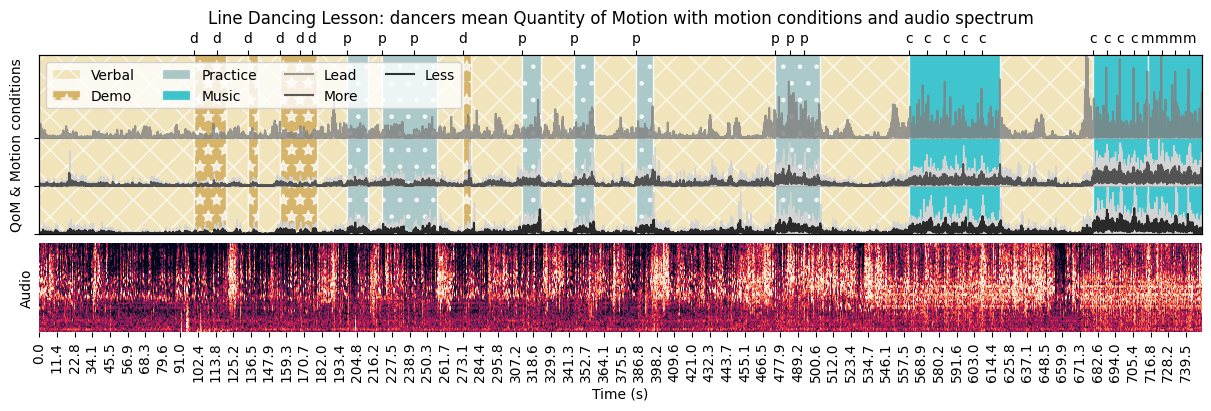

In [78]:
fig3 = plt.figure(constrained_layout=True,figsize=(12,4))
gs = fig3.add_gridspec(3, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2, :])

# sub_eventTypes = list(sub_events.Trial_Type.unique())
events_types = ['Verbal','Demo','Practice','Music']
eventType_pallet=dict(zip(events_types,['#eddca5','#c99b38','#8fb7b7','#00b0be',]))

ax=axes[0]
for ev in events_types: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.75,label=ev)
for ev in eventType_pallet.keys():
        viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.75)

df_feat =  df_allfeats['ACC_QoM'].astype('float')
x = df_feat.index
sect_tags = ['Lead','More','Less']

sect = 'Lead'
ax.plot(df_feat[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )

shift_d = 2500
for sect_i in range(1,len(sect_tags)):
    sect = sect_tags[sect_i]
    y_minimum = df_feat[sections[sect]].quantile(0.1,axis=1)
    y_maximum = df_feat[sections[sect]].quantile(0.9,axis=1)
    fill = ax.fill_between(x, y_minimum-sect_i*shift_d, y_maximum-sect_i*shift_d, color="lightgrey")
    ax.plot(df_feat[sections[sect]].mean(axis=1)-sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
ax.legend(ncol=4,loc='upper left')
ax.set(yticklabels=[],ylabel='QoM & Motion conditions') 
ax.grid()

ax.set_title('Line Dancing Lesson: dancers mean Quantity of Motion with motion conditions and audio spectrum')
ax.set(xlim = [s_time,e_time],ylim = [-2*shift_d,1.7*shift_d],xticks=[],yticks=[0,-shift_d,-shift_d*2])
ax1 = ax.twiny()
ax1.set(xticks = Event_Details.loc[:,'TIME'],xticklabels=Event_Details.loc[:,'LABEL'].str[0],xlim = [s_time,e_time])

ax=axes[1] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./plots/Fig2_LineDancing_Timeline.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Classification of participants by more or less coordinated
Use participants alignment in step timing from vertical acceleration correlation with the lead dancer 

In [33]:
altT2 = np.arange(-10,770,0.01)
df = pd.DataFrame(index = altT2, columns = collist)

ylabs = ['ACC_Vert','ACC_Lat','ACC_Long']
for t in ylabs:
    all_sigs[t] = df.copy()
    
for pname in collist:
    req = df_datafiles.loc[pname,:]
    
    V = pd.read_csv(req['BACCloc'],skipinitialspace=True)
#     V['rec_dTime']=pd.to_datetime(V['rec_dTime'])#.dt.tz_localize(None)
    V_seg=V.copy()
    times = V_seg[time_c]
    f = interpolate.interp1d(times,V_seg['Vert Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Vert'].loc[:,pname] = f(altT2)
    f = interpolate.interp1d(times,V_seg['Lat Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Lat'].loc[:,pname] = f(altT2)
    f = interpolate.interp1d(times,V_seg['Long Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Long'].loc[:,pname] = f(altT2)
    # f = interpolate.interp1d(times,V_seg['qom'],kind = 'linear')    
    # all_sigs['ACC_QoM'].loc[:,pname] = f(altT2)

In [36]:
def xcov(datax, datay,maxlag=10):
    # https://stackoverflow.com/questions/33171413/cross-correlation-time-lag-correlation-with-pandas
    rs = []
    for i in range(-maxlag,maxlag):
        rs.append(datax.corr(datay.shift(i)))
    return rs

In [49]:
max_offs = 0.5

Corrings = pd.DataFrame(columns = ['Trail','StartTime','Dur','Trial_Type', 'Tempo','Feature','PartID','Ref','0corr','maxCorr','maxShift'])
corred = {}
feats = ['ACC_Vert','ACC_Lat','ACC_Long'] #,'Respdiff','normHR1bt'
dur = 30
buff = 1
xcorred = pd.DataFrame()

sf = 100
xcorred['shift_s'] = np.round(np.linspace(-max_offs,max_offs,int(2*max_offs*sf), endpoint=False),2)
Lead = 'AU817'

k = 0
for j,row in Event_Details.iterrows():
    max_offs = 0.5
    if np.isnan(row['Tempo']) is False: max_offs = 40/row['Tempo'] #just under beat length
    corred['Trail'] = row['LABEL']
    corred['Trial_Type'] = row['Trial_Type']
    corred['Tempo'] = row['Tempo']
    seg_start = row['StartTime'] - buff 
    corred['StartTime'] = row['StartTime'] 
    corred['Dur'] = row['Dur']
    seg_end = row['EndTime'] + buff 
    for i in range(len(feats)):
        feat_tag = feats[i]
        corred['Feature'] = feat_tag
        seg_df = all_sigs[feat_tag].loc[seg_start:seg_end,:].astype('float')
        seg_df['Mean'] = seg_df.mean(axis=1)
        C = seg_df.corr()
        for partID in collist[1:]: # after lead
            corred['PartID'] = partID
            for ref in [Lead,'Mean']:
                corred['Ref'] = ref
                corred['0corr'] =C.loc[ref,partID]
                xcorred['r'] = xcov(seg_df[ref], seg_df[partID],int(max_offs*sf))
                corred['maxShift'] = xcorred.loc[xcorred['r'].argmax(),'shift_s']
                corred['maxCorr'] = xcorred['r'].max()

                Corrings.loc[k,:] = corred.copy()
                k+=1


In [79]:
CorrOrder =  ['AU819','AU812', 'AU808',  'AU813',  'AU801', 'AU810', 'AU804',
              'AU815', 'AU807','AU814','AU803', 'AU806','AU802', 'AU818']
sections = {'Lead':['AU817'],
           'More':['AU819','AU812', 'AU808', 'AU813',  'AU801', 'AU810', 'AU804',],
           'Less':['AU815', 'AU807','AU814','AU803', 'AU806','AU802', 'AU818']}
# sections = {'Lead':['AU817'],
#            'More':['AU819', 'AU808', 'AU812', 'AU802', 'AU813', 'AU807', 'AU801'],
#            'Less':['AU804','AU814','AU803', 'AU810', 'AU815', 'AU806','AU818']}

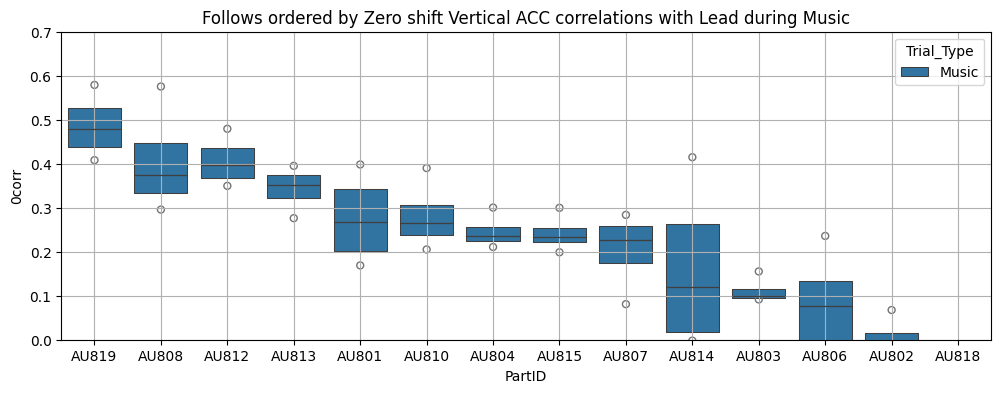

In [73]:
ref= 'AU817'
goodtypes = ['Music']
feats = ['ACC_Vert']
tag_P = 'PartID'
tag_Q = 'Trial_Type'
tag_m = '0corr'#'maxCorr'
sub_Corrings = Corrings.query('Ref==@ref and Feature in @feats and Trial_Type in @goodtypes')
f, (ax1) = plt.subplots(1, 1,figsize=(12,4))

sns.boxenplot(x = tag_P,y = tag_m, hue = tag_Q,hue_order = goodtypes,order = CorrOrder,data = sub_Corrings,ax=ax1)
plt.grid()
plt.ylim([0,0.7])
plt.title('Follows ordered by Zero shift Vertical ACC correlations with Lead during Music')
plt.savefig('_'.join(['./plots/Vert_Max_Part_Order.png']),bbox_inches = 'tight',dpi = 200)
plt.show()

# Laughter and Heart Rate plot with Annotations

In [80]:
An = []
An.append({'x':33,'y':0.35,'text':'A','xytext':(-20, 15)})
An.append({'x':123,'y':0.35,'text':'B','xytext':(-20, 15)})
An.append({'x':395,'y':0.6,'text':'C','xytext':(-20, 15)})
An.append({'x':450,'y':0.4,'text':'D','xytext':(-20, 15)})
An.append({'x':492,'y':0.75,'text':'E','xytext':(-20, 15)})
An.append({'x':506,'y':0.85,'text':'F','xytext':(-20, 15)})
An.append({'x':533,'y':0.6,'text':'G','xytext':(-10, 20)})
An.append({'x':608,'y':0.85,'text':'H','xytext':(-20, 15)})
An.append({'x':715,'y':1.05,'text':'I','xytext':(-20, 15)})
Annotations = pd.DataFrame(An)

In [99]:
s_time = times[0]
e_time = altT[-1]

sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.Trial_Type.unique())


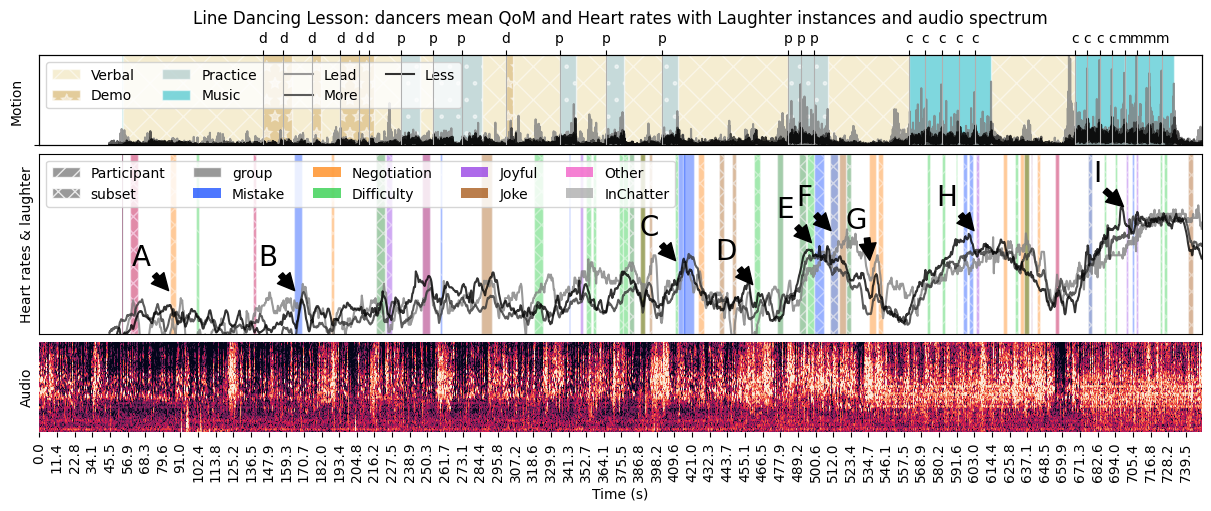

In [100]:
fig3 = plt.figure(constrained_layout=True,figsize=(12,5))
gs = fig3.add_gridspec(4, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0, :])
axes[1] = fig3.add_subplot(gs[1:3, :])
axes[2] = fig3.add_subplot(gs[3, :])

ax=axes[0]
for ev in sub_eventTypes: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
df_feat =  df_allfeats['ACC_QoM'].astype('float')
x = df_feat.index
sect_tags = ['Lead','More','Less']

shift_d = 2500
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)-sect_i,color =section_pallet[sect],alpha=0.8,label=sect )
ax.legend(ncol=4,loc='upper left')
ax.set(yticklabels=[],ylabel='Motion') 
ax.grid()
ax.set_title('Line Dancing Lesson: dancers mean QoM and Heart rates with Laughter instances and audio spectrum')
ax.set(xlim = [s_time,e_time],ylim = [0,1.7*shift_d],xticks=[],yticks=[0])
ax1 = ax.twiny()
ax1.set(xticks = Event_Details.loc[:,'TIME'],xticklabels=Event_Details.loc[:,'LABEL'].str[0],xlim = [s_time,e_time])
ax1.grid()

ax=axes[1]
A = laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
for who in ['Participant','subset', 'group']:
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.legend(ncol=5,loc='upper left')

df_feat =  df_allfeats['normHR1bt'].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_smoothed[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(xlim = [s_time,e_time],ylim = [0,1.5],xticks=[],yticks=[])
ax.grid()
# ax.legend()
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset', 'Lead', 'few', 'group', 'Participant']:
    sub_laughs = laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.4)

for i,row in Annotations.iterrows():
    ax.annotate(row['text'],xy=(row['x'],row['y']), xycoords='data',
            xytext=row['xytext'], textcoords='offset points', arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='center', verticalalignment='bottom', fontsize=20)      
ax=axes[2] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

plt.savefig('./plots/Fig5_LineDancing_Laughter.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Quantified stats around laughter and dancing intervals

In [87]:
df_feat1 =  df_allfeats['ACC_QoM'].astype('float').copy()
df_feat2 =  df_allfeats['normHR1bt_smoothed'].astype('float').copy()

In [90]:
laughs['Dur'] = laughs['DURATION']

df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat1.columns))
A = []
for i,row in Event_Details.iterrows():
    k = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
QoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat1.columns))
A = []
k = df_feat1.mean()
for i,row in Event_Details.iterrows():
    
    K = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat1.loc[row['TIME']-5:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dQoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat2.columns))
A = []
for i,row in Event_Details.iterrows():
    k = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
nHR_even_means = pd.concat(A,axis=1).transpose()


df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat2.columns))
A = []
for i,row in Event_Details.iterrows():
    K = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat2.loc[row['TIME']-5:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dHR_even_means = pd.concat(A,axis=1).transpose()

Event_means = QoM_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_Mean")
Event_means["QoM_Mean"] = Event_means["QoM_Mean"].astype('float')
B = dQoM_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_dMean")
Event_means["QoM_dMean"] = B["QoM_dMean"].astype('float')
B = nHR_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_Mean")
Event_means["HR_Mean"] = B["HR_Mean"].astype('float')
B = dHR_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_dMean")
Event_means["HR_dMean"] = B["HR_dMean"].astype('float')
# Event_means

In [91]:
df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat1.columns))
A = []
for i,row in laughs.iterrows():
    k = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
QoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat1.columns))
A = []
k = df_feat1.mean()
for i,row in laughs.iterrows():
    
    K = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat1.loc[row['TIME']-5:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dQoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat2.columns))
A = []
for i,row in laughs.iterrows():
    k = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
nHR_even_means = pd.concat(A,axis=1).transpose()


df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat2.columns))
A = []
for i,row in laughs.iterrows():
    K = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat2.loc[row['TIME']-5:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dHR_even_means = pd.concat(A,axis=1).transpose()

Even_means = QoM_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_Mean")
Even_means["QoM_Mean"] = Even_means["QoM_Mean"].astype('float')
B = dQoM_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_dMean")
Even_means["QoM_dMean"] = B["QoM_dMean"].astype('float')
B = nHR_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_Mean")
Even_means["HR_Mean"] = B["HR_Mean"].astype('float')
B = dHR_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_dMean")
Even_means["HR_dMean"] = B["HR_dMean"].astype('float')
# Even_means

In [92]:
laugh_means = Even_means.copy()

sub_laugh_means = laugh_means.query('Who=="group"').copy()

In [93]:
pg.rm_anova(data = sub_laugh_means,dv = 'HR_Mean',subject = 'partID',within='TIME')

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,TIME,13,182,25.653894,1.685480e-34,0.562186,0.385363


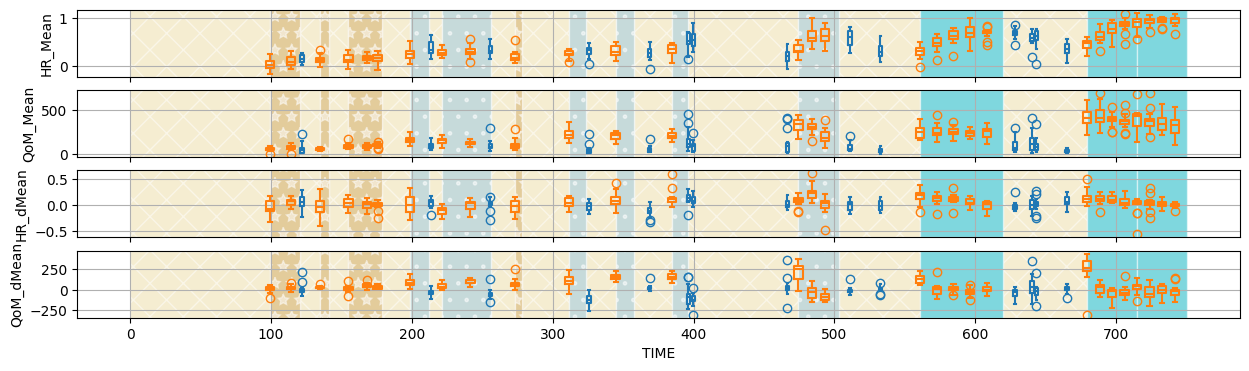

In [94]:
fig, axes = plt.subplots(4,1,sharex=True,figsize=(15,4))
ax = axes[0]
sns.boxplot(x='TIME', y='HR_Mean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='HR_Mean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
ax = axes[1]
ax = sns.boxplot(x='TIME', y='QoM_Mean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='QoM_Mean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
ax = axes[2]
ax = sns.boxplot(x='TIME', y='HR_dMean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='HR_dMean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
ax = axes[3]
ax = sns.boxplot(x='TIME', y='QoM_dMean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='QoM_dMean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()

plt.savefig('./plots/Phys_Changes_LineDancing.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Laughter counts

In [101]:
laughs.value_counts('Who')

Who
subset         39
group          14
Lead            3
Participant     3
few             2
Name: count, dtype: int64

In [95]:
Laugh_Counts = pd.DataFrame(index = whats, columns = events_types,data = 0)
for i,row in Event_timings.iterrows():
    s_time = row['StartTime']
    e_time = row['EndTime']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
    Laugh_Counts.loc[whats,row['Trial_Type']]+=sub_laughs.loc[:,whats].sum()

Laugh_Counts.transpose()

,Mistake,Negotiation,Difficulty,Novelty,Joyful,Joke,Other,InChatter
Verbal,4,14,14,0,3,5,4,11
Demo,0,0,0,0,0,0,0,0
Practice,3,1,5,0,0,0,0,2
Music,4,0,8,0,3,0,0,1


In [96]:
print(Laugh_Counts.transpose().to_latex())

\begin{tabular}{lrrrrrrrr}
\toprule
 & Mistake & Negotiation & Difficulty & Novelty & Joyful & Joke & Other & InChatter \\
\midrule
Verbal & 4 & 14 & 14 & 0 & 3 & 5 & 4 & 11 \\
Demo & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
Practice & 3 & 1 & 5 & 0 & 0 & 0 & 0 & 2 \\
Music & 4 & 0 & 8 & 0 & 3 & 0 & 0 & 1 \\
\bottomrule
\end{tabular}

